# Wstęp
Zadanie 8 obejmuje zagadnienie segmentacji obrazów i wprowadza konwolucyjne modele o architekturze enkoder-dekoder. Modele takie wykorzystują konwolucje i downsampling aby uzyskać mapę cech o mniejszej rozdzielczości (enkoder), a następnie "dekodują" otrzymaną ją z powrotem do większej rozdzielczości aby wydobyć w rozdzielczości oryginalnego obrazka interesujące nas informacje semantyczne - np. segmentację obrazka na poszczególne obiekty. Architektury tego typu mają również zastosowania w modelach generatywnych, w zadaniach które ogólnie określamy jako *image to image translation*.

# Cel ćwiczenia

Celem ćwiczenia jest poznanie



*   metod upsamplingu w sieciach konwolucyjnych
*   architektur konwolucyjnych o strukturze enkoder-dekoder
*   wykorzystania sieci głębokich w segmentacji danych obrazowych





# Upsampling w sieciach konwolucyjnych

Na laboratorium 5 dowiedzieliśmy się już, że do zmniejszania rozdzielczości mapy cech możemy wykorzystać dwa podejścia - pooling lub warstwę konwolucyjną z odpowiednim parametrem `stride`. Podobnie jest ze zwiększaniem rozdzielczości.

Wersja prostsza, odwrotność poolingu, to `torch.nn.Upsample`. Jest to pozbawiona uczących się parametrów klasa dająca wybór trybu interpolacji.

In [1]:
import torch

upsampler = torch.nn.Upsample(scale_factor=2)

dummy_input = torch.zeros((3,3,32,32))
upsampler(dummy_input).shape

torch.Size([3, 3, 64, 64])

Klasa `torch.nn.ConvTranspose2d` to natomiast ucząca się operacja "odwracania" konwolucji. Jej relacja wymiarów wejście-wyjście powinna być taka, jak wyjście do wejścia dla warstwy `torch.nn.Conv2d` o analogicznych parametrach konstruktora. Innymi słowy, jeśli tensor przepuścimy przez konwolucję, a następnie konwolucję transponowaną, oczekujemy powrotu do początkowej szerokości i wysokości - o ile oczywiście parametry tych dwóch warstw będą się ze sobą zgadzać.

Konwolucja transponowana wprowadza dodatkowy parametr `output_padding`. Jest on potrzebny dlatego, że ze względu na zaokrąglanie wymiarów dla zwyczajnej konwolucji wykorzystującej `stride>1`, na podstawie wymiaru jej wyjścia nie da się jednoznacznie określić wymiaru jej wejścia. Aby spełnić założenie że warstwa `torch.nn.ConvTranspose2d` odwraca zmianę wymiarów której dokonuje `torch.nn.Conv2d`, potrzebny jest więc dodatkowy parametr pozwalający doprecyzować oczekiwany rozmiar. W razie problemów z uzyskaniem właściwego rozmiaru, dokumentacja torcha podaje konkrenty wzór na zależność między parametrami warstwy a szeokością i wysokością jej wyniku.

https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html

In [2]:
upsampler = torch.nn.ConvTranspose2d(3,3,2, stride=2)

dummy_input = torch.zeros((3,3,32,32))

print(f"kształt po upsamplingu: {upsampler(dummy_input).shape}")

conv = torch.nn.Conv2d(3,3,3, stride=2, padding=1)
deconv = torch.nn.ConvTranspose2d(3,3,3, stride=2, padding=1)
fixed_deconv = torch.nn.ConvTranspose2d(3,3,3, stride=2, padding=1, output_padding=1)

print(f"kształt po konwolucji: {conv(dummy_input).shape}")
print(f"kształt po konwolucji i konw. transponowanej: {deconv(conv(dummy_input)).shape}")
print(f"j.w., ale z output_padding: {fixed_deconv(conv(dummy_input)).shape}")

kształt po upsamplingu: torch.Size([3, 3, 64, 64])
kształt po konwolucji: torch.Size([3, 3, 16, 16])
kształt po konwolucji i konw. transponowanej: torch.Size([3, 3, 31, 31])
j.w., ale z output_padding: torch.Size([3, 3, 32, 32])


# Segmentacja obrazu

Model enkoder-dekoder testować będziemy w zadaniu nadzorowanej segmentacji. Oznacza to, że dla obrazu wejściowego musimy znaleźć etykiety ze z góry wyznaczonego zbioru, przewidujemy je jednak nie dla całego obrazu, a na poziomie każdego piksela. Skorzystamy z dostępnego w `torchvision.datasets` zbioru VOC. Najpierw jednak musimy zdefiniować transformację danych, kóra będzie nieco bardziej skomplikowana niż do tej pory.

Ponieważ etykiety są podane również jako obraz, trzeba pamiętać, że augmentacje losowe muszą zgadzać się pomiędzy obrazkiem a etykietą. Niestety, każde wywołanie funkcji w standardowym przepływie danych z wykorzystaniem `transforms` losuje augmentację na nowo. Aby uzyskać identyczną augmentację, konieczne będzie wykorzystanie funkcji z `torchvision.transforms.functional`.

Druga istotna zmiana to konwersja do tensora. Aby zachować `target` jako tensor całkowitoliczbowy, musimy zastosować własną alternatywę dla ToTensor(), jako że `ToTensor` zawsze przekształca obrazy do tensora zmiennmoprzecinkowego w zakresie [0,1].

# Zadanie 1

Zdefiniuj transformację, która dla pary wejściowej `image, target` zwraca zaugmentowane w identyczny sposób obraz i etykiety. Transformacja powinna obejmować:

*   dowolną augmentację na danych wejściowych
*   padding to stałego rozmiaru (w przypadku etykiet, padować trzeba wartością 255)
*   konwersję do tensora - zmiennoprzecinkowego dla obrazu, całkowitoliczbowego dla etykiety

Zdefiniuj również odpowiednią transformację dla zbioru testowego, pamiętając że dane testowe nie powinny byc augmentowane.



In [3]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import numpy as np
import PIL
import random
import torch

def pair_transforms(image, target):
    # Resize (zmniejszenie do 1/4 rozdzielczości dla oszczędności)
    resize = transforms.Resize((image.size[1]//4, image.size[0]//4), PIL.Image.NEAREST)
    image = resize(image)
    target = resize(target)

    # Padding do stałego rozmiaru (musi być >= największy obraz w zbiorze)
    # VOC po resize ~(125, 125) max, weźmy 128x128
    pad_h = max(0, 128 - image.size[1])
    pad_w = max(0, 128 - image.size[0])
    # padding: (left, top, right, bottom)
    image  = TF.pad(image,  [0, 0, pad_w, pad_h], fill=0)
    target = TF.pad(target, [0, 0, pad_w, pad_h], fill=255)  # 255 = ignore

    # Losowe horizontal flip – to samo dla obu!
    if random.random() > 0.5:
        image  = TF.hflip(image)
        target = TF.hflip(target)

    # Konwersja do tensorów
    out_image  = TF.to_tensor(image)                          # float [0,1]
    out_target = torch.as_tensor(np.array(target), dtype=torch.long)  # int64

    # Uproszczenie: tło=0, obiekt=1, granica=255 (ignore)
    out_target = torch.where(
        torch.logical_or(out_target == 0, out_target == 255),
        out_target,
        torch.ones_like(out_target)
    )

    return out_image, out_target


def test_pair_transforms(image, target):
    resize = transforms.Resize((image.size[1]//4, image.size[0]//4), PIL.Image.NEAREST)
    image = resize(image)
    target = resize(target)

    pad_h = max(0, 128 - image.size[1])
    pad_w = max(0, 128 - image.size[0])
    image  = TF.pad(image,  [0, 0, pad_w, pad_h], fill=0)
    target = TF.pad(target, [0, 0, pad_w, pad_h], fill=255)

    # Brak augmentacji dla testu!
    out_image  = TF.to_tensor(image)
    out_target = torch.as_tensor(np.array(target), dtype=torch.long)

    out_target = torch.where(
        torch.logical_or(out_target == 0, out_target == 255),
        out_target,
        torch.ones_like(out_target)
    )

    return out_image, out_target

Załaduj zbiór danych ze zeefiniowaną transformacją, a następnie zweryfikuj, że augmentacja zgadza się pomiędzy obrazem a etykietą.

In [4]:
data = datasets.VOCSegmentation("root", download=True, transforms=pair_transforms)

100%|██████████| 2.00G/2.00G [14:14<00:00, 2.34MB/s]


In [5]:
test_data = datasets.VOCSegmentation("root", download=True, image_set="val", transforms=test_pair_transforms)

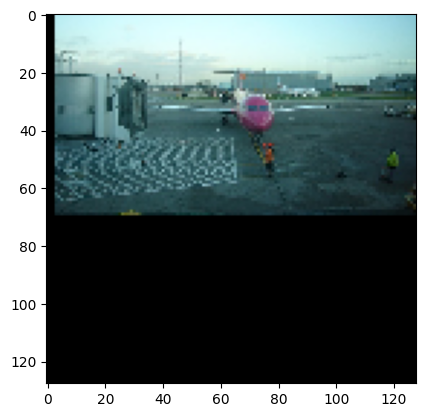

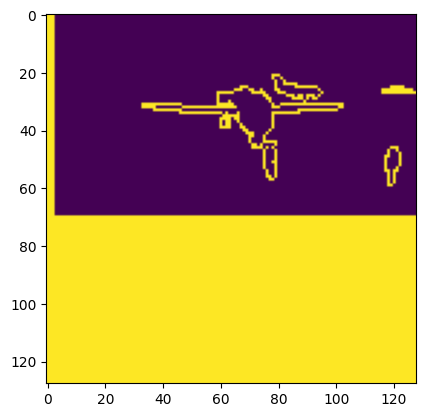

tensor([[255, 255, 255,  ...,   0,   0,   0],
        [255, 255, 255,  ...,   0,   0,   0],
        [255, 255, 255,  ...,   0,   0,   0],
        ...,
        [255, 255, 255,  ..., 255, 255, 255],
        [255, 255, 255,  ..., 255, 255, 255],
        [255, 255, 255,  ..., 255, 255, 255]])


In [6]:
from matplotlib import pyplot as plt

image, label = data[0]
plt.imshow(image.permute(1,2,0))
plt.show()
plt.imshow(label)
plt.show()
print(label)

Zauważ, że wartością 255 oznaczone są "krawędzie" pomiędzy właściwymi etykietami. Etykieta 255 nie powinna być brana pod uwagę przy wyliczaniu kosztu i metryk jakości segmentacji.

# Architektura enkoder-dekoder


Możemy przejść do zdefiniowania architektury enkoder-dekoder. Achitektura ta powinna przetworzyć obraz do niższej rozdzielczości, a następnie zwiększyć jego wymiar z powrotem do oryginalnego. Podobnie jak w standardowych sieciach konwolucyjnych do klasyfikacji, przydatne jest zwiększanie liczby kanałów wraz ze zmniejszaniem rozdzielczości. Pozwala to na zachowanie informacji po downsamplingu, oraz daje możliwość wyuczenia najbardziej złożonych zależności tam gdzie jest to najbardziej istotne, czyli w warstwach operujących na najniższej rozdzielczości gdzie pole recepcyjne filtra obejmuje największy fragment obrazu. Przy upsamplingu, liczba kanałów typowo będzie się zmniejszać. Dodatkowo, skrótowe połączenia według schematu: pierwsza warstwa do ostatniej, druga do przedostaniej etc. są typowym elementem takich architektur.

# Zadanie 2

Zmodyfikuj strukturę sieci i funkcję forward SimpleEncoderDecoder tak, aby dodać połączenia skrótowe między warstwami o tej samej rozdzielczości.

In [7]:
class SimpleEncoderDecoder(torch.nn.Module):
    def __init__(self, channels, out_labels):
        super().__init__()
        # Enkoder
        self.conv_1 = torch.nn.Conv2d(3, channels[0], 3, padding=1)
        self.conv_2 = torch.nn.Conv2d(channels[0], channels[1], 3, padding=1)
        self.conv_3 = torch.nn.Conv2d(channels[1], channels[2], 3, padding=1)
        # Bottleneck
        self.conv_4 = torch.nn.Conv2d(channels[2], channels[2], 3, padding=1)
        # Dekoder
        self.up_conv1 = torch.nn.ConvTranspose2d(channels[2], channels[1], 2, stride=2)
        self.up_conv2 = torch.nn.ConvTranspose2d(channels[1], channels[0], 2, stride=2)
        self.up_conv3 = torch.nn.ConvTranspose2d(channels[0], out_labels, 2, stride=2)

        self.pool  = torch.nn.MaxPool2d(2)
        self.act   = torch.nn.ReLU()
        self.bnorm = torch.nn.BatchNorm2d(channels[2])

    def forward(self, x):
        # Enkoder – zapisujemy skip connections
        s1 = self.act(self.conv_1(x))       # rozdzielczość H x W
        x  = self.pool(s1)

        s2 = self.act(self.conv_2(x))       # rozdzielczość H/2 x W/2
        x  = self.pool(s2)

        s3 = self.act(self.conv_3(x))       # rozdzielczość H/4 x W/4
        x  = self.pool(s3)

        # Bottleneck
        x = self.bnorm(x)
        x = self.act(self.conv_4(x))        # rozdzielczość H/8 x W/8

        # Dekoder + skip connections (dodawanie)
        x = self.act(self.up_conv1(x)) + s3  # H/4 x W/4
        x = self.act(self.up_conv2(x)) + s2  # H/2 x W/2
        x = self.up_conv3(x) + s1            # H x W  (bez ReLU na końcu – logity!)

        return x

Zweryfikuj działanie sieci:

In [8]:
model = SimpleEncoderDecoder([32,64,128], 21).cuda()

dummy_data = torch.zeros((32,3,64,64)).cuda()

assert(model(dummy_data).shape==(32,21,64,64))

AssertionError: Torch not compiled with CUDA enabled

# Zadanie 3

Zdefinuj kod pętli uczącej i validacji, pamiętając że wartości 255 powinny być ignorowane. Funkcją kosztu ma być entropia krzyżowa na poziomie pikseli.

Standardowa metryka accuracy może być zafałszowana przez nizbalansowanie między klasami tła a obiektów. Do validate, względem poprzednich laboratoriów, dodaj więc wyliczanie metryki Intersection over Union (IoU). (Teraz powinna ona zwracać trójkę (koszt, accuracy, IoU))

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from typing import Tuple

def validate(
    model: nn.Module,
    loss_fn: torch.nn.CrossEntropyLoss,
    dataloader: DataLoader
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:

    model.eval()
    total_loss = 0.0
    correct = 0
    total_pixels = 0

    # IoU: akumulujemy TP, FP, FN dla każdej klasy (tu: 0 i 1)
    num_classes = 2
    intersection = torch.zeros(num_classes)
    union        = torch.zeros(num_classes)

    with torch.no_grad():
        for images, targets in dataloader:
            images  = images.cuda()
            targets = targets.cuda()

            outputs = model(images)                          # (B, C, H, W)
            loss    = loss_fn(outputs, targets)
            total_loss += loss.item()

            preds = outputs.argmax(dim=1)                    # (B, H, W)
            mask  = targets != 255                           # ignorujemy granice

            correct      += (preds[mask] == targets[mask]).sum().item()
            total_pixels += mask.sum().item()

            # IoU per klasa
            for cls in range(num_classes):
                pred_cls   = (preds == cls) & mask
                target_cls = (targets == cls) & mask
                intersection[cls] += (pred_cls & target_cls).sum().item()
                union[cls]        += (pred_cls | target_cls).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total_pixels
    iou_per_class = intersection / (union + 1e-8)
    mean_iou = iou_per_class.mean().item()

    return avg_loss, accuracy, mean_iou


def fit(
    model: nn.Module,
    optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss,
    train_dl: DataLoader,
    val_dl: DataLoader,
    epochs: int,
    print_metrics: bool = True
):
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for images, targets in train_dl:
            images  = images.cuda()
            targets = targets.cuda()

            optimiser.zero_grad()
            outputs = model(images)
            loss    = loss_fn(outputs, targets)
            loss.backward()
            optimiser.step()

            train_loss += loss.item()

        train_loss /= len(train_dl)
        val_loss, val_acc, val_iou = validate(model, loss_fn, val_dl)

        if print_metrics:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train loss: {train_loss:.4f} | "
                  f"Val loss: {val_loss:.4f} | "
                  f"Val acc: {val_acc:.3f} | "
                  f"Val IoU: {val_iou:.3f}")

Wyucz sieć na danych z VOCSegmentation.

Uwaga: VOCSegmentation to dość trudny zbiór, nie trzeba tu osiągać wyjątkowo dobrych wyników.



In [ ]:
model = SimpleEncoderDecoder([32,64,128], 2).cuda()

loss = torch.nn.CrossEntropyLoss(ignore_index=255)
train_dl = DataLoader(data, batch_size=32, shuffle=True)
test_dl = DataLoader(test_data, batch_size=32)
optimizer = optim.Adam(model.parameters())

fit(model, optimizer, loss, train_dl, test_dl, 50, True)

# Zadanie 4

Zdefiniuj parametryzowalną klasę EncoderDecoder, umożliwiającą wybór liczby warstw i liczby kanałów w poszczególnych warstwach. Klasa powinna dodawać połączenia skrótowe pomiędzy warstwami w początkowej a końcowej części architektury o tej samej rozdzielczości. Połączenia skrótowe powinny działać przez dodawanie.

Klasa powinna umożlwiać wybór pomiędzy upsamplingiem z wykorzsytaniem `ConvTranspose2D` a `torch.nn.Upsample`. Sprawdź wyniki tej drugiej opcji z parametrami analogicznymi do testów `SimpleEncoderDecoder` na segmentacji VOC.



In [ ]:
class EncoderDecoder(torch.nn.Module):
    def __init__(self, channels: list, out_labels: int, use_conv_transpose: bool = True):
        """
        channels: lista liczby kanałów dla kolejnych warstw enkodera, np. [32, 64, 128]
        out_labels: liczba klas wyjściowych
        use_conv_transpose: True = ConvTranspose2d, False = nn.Upsample + Conv2d
        """
        super().__init__()
        self.use_conv_transpose = use_conv_transpose
        n = len(channels)

        # Enkoder: Conv2d dla każdego poziomu
        in_ch = [3] + channels[:-1]
        self.enc_convs = nn.ModuleList([
            nn.Conv2d(in_ch[i], channels[i], 3, padding=1)
            for i in range(n)
        ])

        # Bottleneck
        self.bottleneck = nn.Conv2d(channels[-1], channels[-1], 3, padding=1)

        # Dekoder: odwrotna kolejność kanałów
        dec_in  = list(reversed(channels))          # [128, 64, 32]
        dec_out = list(reversed(channels[:-1])) + [out_labels]  # [64, 32, out_labels]

        if use_conv_transpose:
            self.dec_convs = nn.ModuleList([
                nn.ConvTranspose2d(dec_in[i], dec_out[i], 2, stride=2)
                for i in range(n)
            ])
        else:
            # Upsample + zwykła Conv (zachowuje kanały po upsamplu, potem redukuje)
            self.upsamplers = nn.ModuleList([
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
                for _ in range(n)
            ])
            self.dec_convs = nn.ModuleList([
                nn.Conv2d(dec_in[i], dec_out[i], 3, padding=1)
                for i in range(n)
            ])

        self.pool = nn.MaxPool2d(2)
        self.act  = nn.ReLU()
        self.bnorm = nn.BatchNorm2d(channels[-1])

    def forward(self, x):
        skips = []

        # Enkoder
        for conv in self.enc_convs:
            x = self.act(conv(x))
            skips.append(x)
            x = self.pool(x)

        # Bottleneck
        x = self.bnorm(x)
        x = self.act(self.bottleneck(x))

        # Dekoder z skip connections (odwrotna kolejność skipów)
        skips = list(reversed(skips))

        for i, dec_conv in enumerate(self.dec_convs):
            if self.use_conv_transpose:
                x = dec_conv(x)
            else:
                x = self.upsamplers[i](x)
                x = dec_conv(x)

            # Skip connection przez dodawanie (ostatnia warstwa → out_labels kanałów, nie pasuje do skipa)
            if i < len(skips) and x.shape == skips[i].shape:
                x = x + skips[i]

            # ReLU wszędzie oprócz ostatniej warstwy
            if i < len(self.dec_convs) - 1:
                x = self.act(x)

        return x